<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [29]:
#!pip install pandas
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.collections import PolyCollection
import numpy as np
from matplotlib.colors import Normalize
from collections import Counter



#### Step 1: Load the dataset


In [ ]:
file_path = "survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




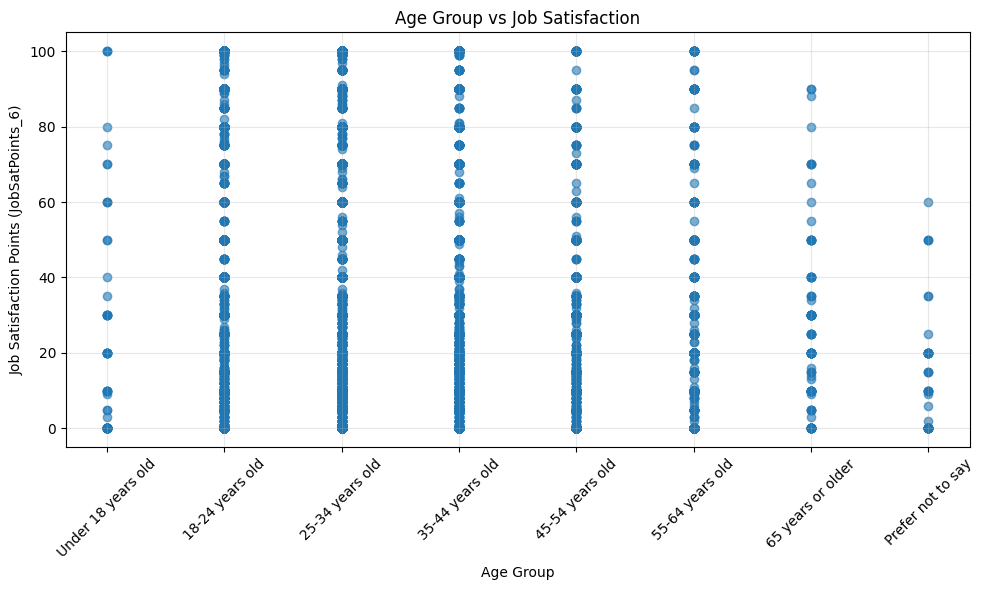

In [37]:
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old',
    '65 years or older', 'Prefer not to say'
]
age_mapping = {age: idx for idx, age in enumerate(age_order)}

df_age = df[['Age', 'JobSatPoints_6']].dropna().copy()
df_age = df_age[df_age['Age'].isin(age_mapping)]
df_age['Age_numeric'] = df_age['Age'].map(age_mapping)

plt.figure(figsize=(10, 6))
plt.scatter(df_age['Age_numeric'], df_age['JobSatPoints_6'], alpha=0.6)
plt.xticks(list(age_mapping.values()), age_order, rotation=45)
plt.title('Age Group vs Job Satisfaction')
plt.xlabel('Age Group')
plt.ylabel('Job Satisfaction Points (JobSatPoints_6)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


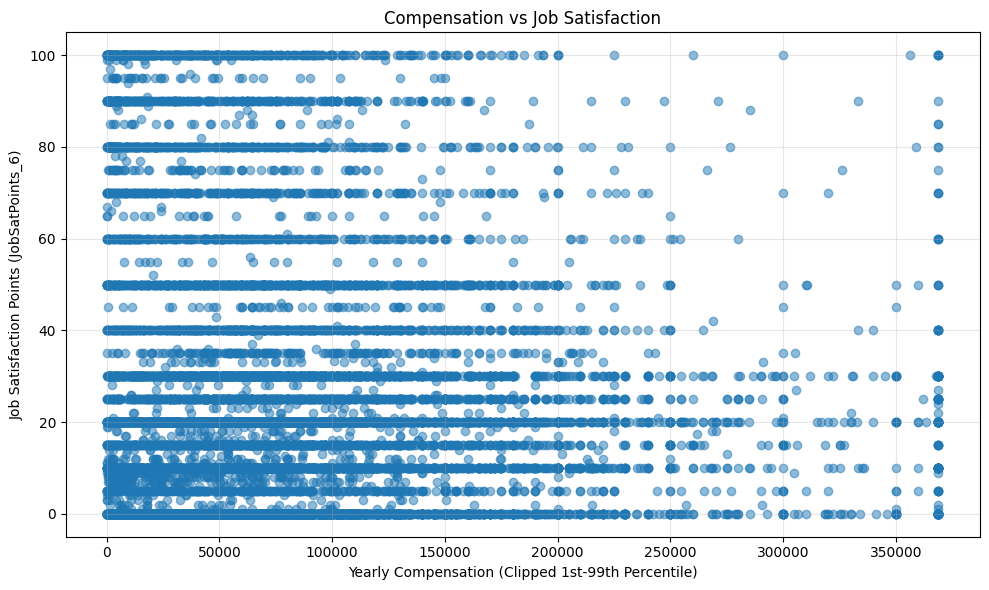

In [41]:
df_comp = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna().copy()
df_comp = df_comp[df_comp['ConvertedCompYearly'] > 0]
comp_min, comp_max = df_comp['ConvertedCompYearly'].quantile([0.01, 0.99])
df_comp['CompClipped'] = df_comp['ConvertedCompYearly'].clip(lower=comp_min, upper=comp_max)

plt.figure(figsize=(10, 6))
plt.scatter(df_comp['CompClipped'], df_comp['JobSatPoints_6'], alpha=0.5)
plt.title('Compensation vs Job Satisfaction')
plt.xlabel('Yearly Compensation (Clipped 1st-99th Percentile)')
plt.ylabel('Job Satisfaction Points (JobSatPoints_6)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


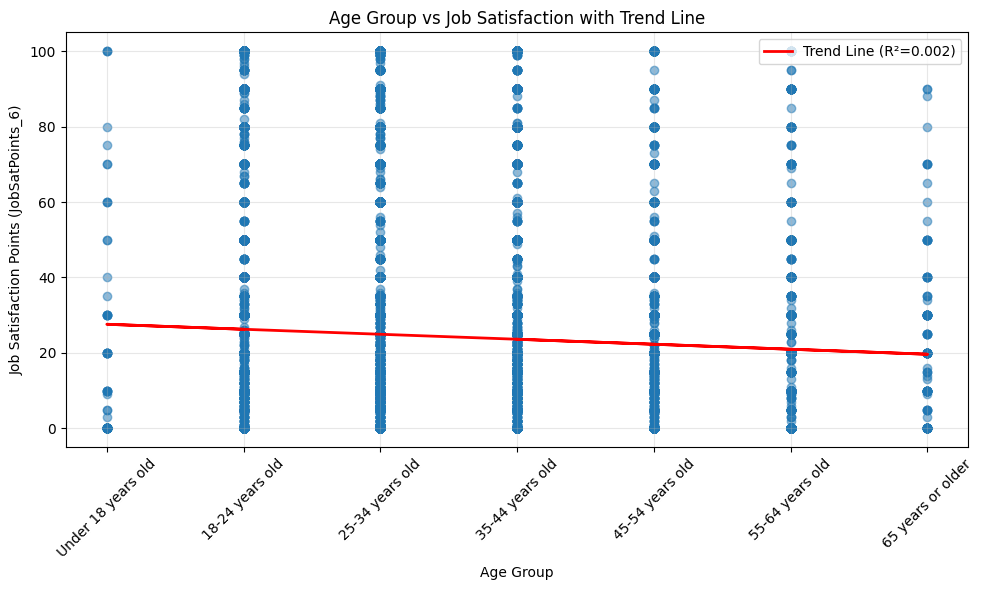

In [44]:
age_mapping = {
    'Under 18 years old': 0,
    '18-24 years old': 1,
    '25-34 years old': 2,
    '35-44 years old': 3,
    '45-54 years old': 4,
    '55-64 years old': 5,
    '65 years or older': 6
}

df_cleaned = df[['Age', 'JobSatPoints_6']].dropna().copy()
df_cleaned = df_cleaned[df_cleaned['Age'].isin(age_mapping)]
df_cleaned['Age_numeric'] = df_cleaned['Age'].map(age_mapping)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_cleaned['Age_numeric'],
    df_cleaned['JobSatPoints_6']
)

plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned['Age_numeric'], df_cleaned['JobSatPoints_6'], alpha=0.5)
plt.plot(
    df_cleaned['Age_numeric'],
    slope * df_cleaned['Age_numeric'] + intercept,
    color='red',
    linewidth=2,
    label=f'Trend Line (R²={r_value**2:.3f})'
)
plt.xticks(list(age_mapping.values()), list(age_mapping.keys()), rotation=45)
plt.title('Age Group vs Job Satisfaction with Trend Line')
plt.xlabel('Age Group')
plt.ylabel('Job Satisfaction Points (JobSatPoints_6)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


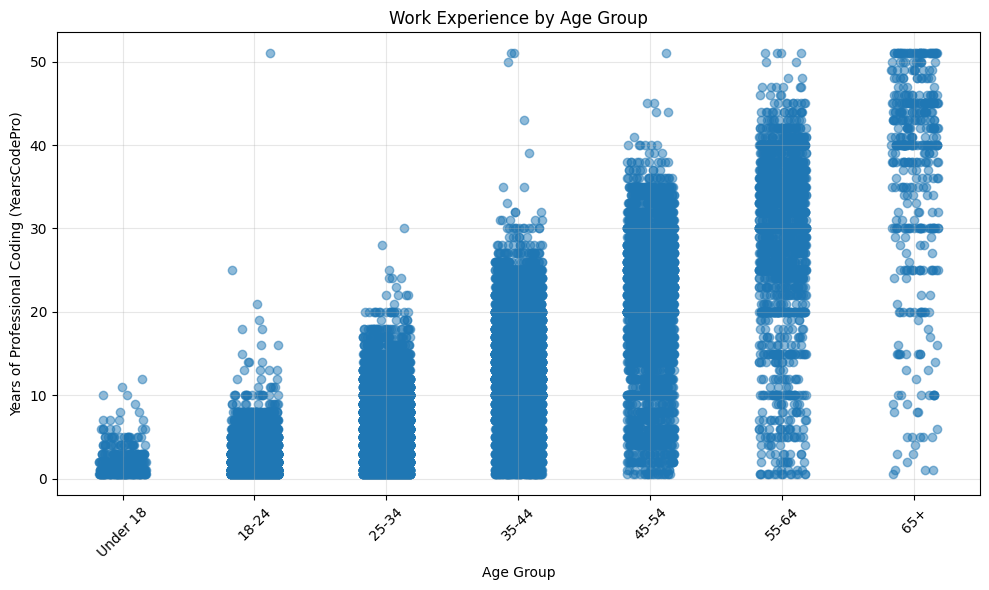

In [47]:
age_labels = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'
}

def parse_years(value):
    if pd.isna(value):
        return np.nan
    if value == 'Less than 1 year':
        return 0.5
    if value == 'More than 50 years':
        return 51
    try:
        return float(value)
    except ValueError:
        return np.nan

work_df = df[['Age', 'YearsCodePro']].dropna().copy()
work_df['Age_group'] = work_df['Age'].map(age_labels)
work_df['YearsCodePro_num'] = work_df['YearsCodePro'].apply(parse_years)
work_df = work_df.dropna(subset=['Age_group', 'YearsCodePro_num'])

age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
work_df['Age_group'] = pd.Categorical(
    work_df['Age_group'],
    categories=age_order,
    ordered=True
)

plt.figure(figsize=(10, 6))
plt.scatter(
    work_df['Age_group'].cat.codes + np.random.uniform(-0.18, 0.18, size=len(work_df)),
    work_df['YearsCodePro_num'],
    alpha=0.5
)
plt.xticks(range(len(age_order)), age_order, rotation=45)
plt.title('Work Experience by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Coding (YearsCodePro)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


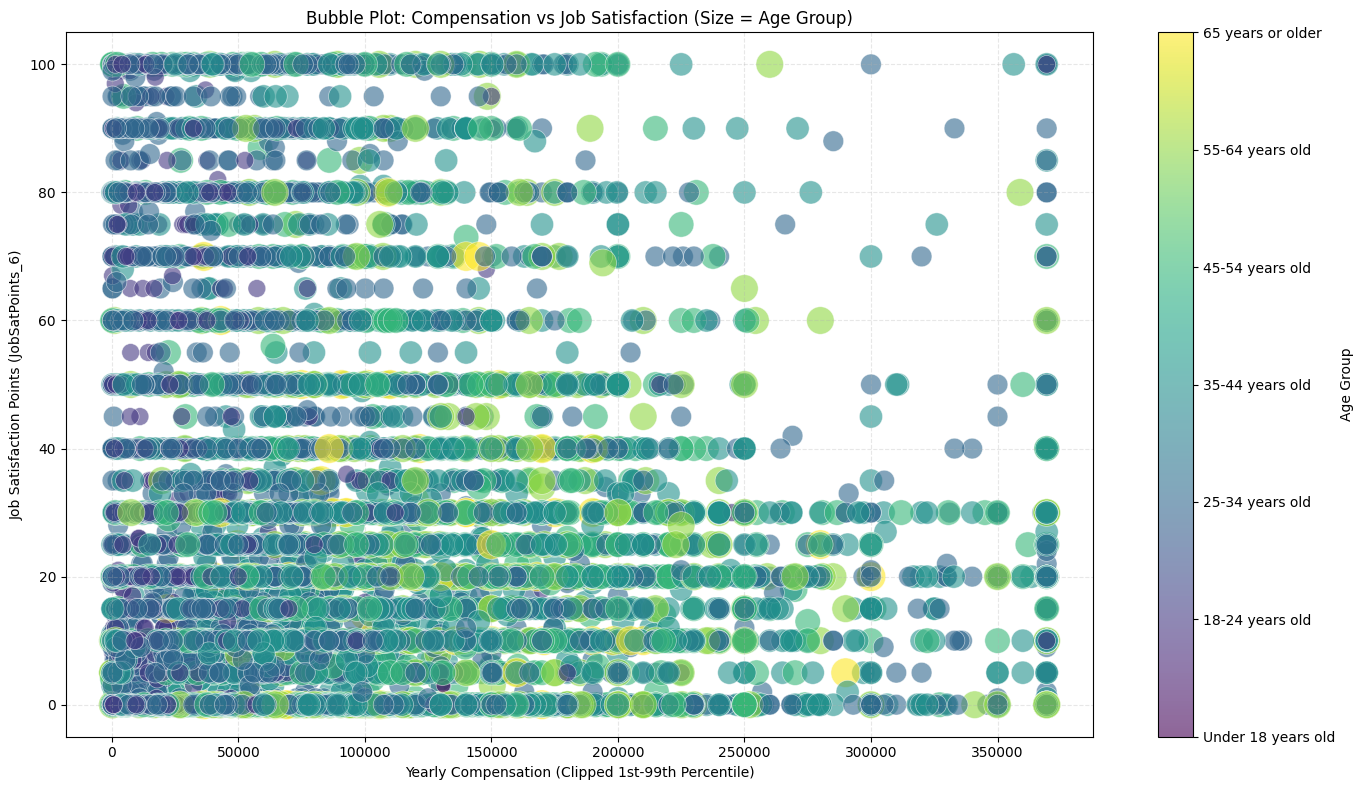

In [48]:
age_mapping = {
    'Under 18 years old': 0,
    '18-24 years old': 1,
    '25-34 years old': 2,
    '35-44 years old': 3,
    '45-54 years old': 4,
    '55-64 years old': 5,
    '65 years or older': 6
}

bubble_df = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna().copy()
bubble_df = bubble_df[bubble_df['Age'].isin(age_mapping)]
bubble_df['Age_numeric'] = bubble_df['Age'].map(age_mapping)
bubble_df['bubble_size'] = ((bubble_df['Age_numeric'] + 1) / len(age_mapping)) * 400 + 50

comp_min, comp_max = bubble_df['ConvertedCompYearly'].quantile([0.01, 0.99])
bubble_df['CompClipped'] = bubble_df['ConvertedCompYearly'].clip(lower=comp_min, upper=comp_max)

sat_min, sat_max = bubble_df['JobSatPoints_6'].quantile([0.01, 0.99])
bubble_df['JobSatClipped'] = bubble_df['JobSatPoints_6'].clip(lower=sat_min, upper=sat_max)

plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    bubble_df['CompClipped'],
    bubble_df['JobSatClipped'],
    s=bubble_df['bubble_size'],
    alpha=0.6,
    c=bubble_df['Age_numeric'],
    cmap='viridis',
    edgecolors='white',
    linewidth=0.5
)
plt.title('Bubble Plot: Compensation vs Job Satisfaction (Size = Age Group)')
plt.xlabel('Yearly Compensation (Clipped 1st-99th Percentile)')
plt.ylabel('Job Satisfaction Points (JobSatPoints_6)')
plt.grid(True, alpha=0.3, linestyle='--')

cbar = plt.colorbar(scatter, ax=plt.gca(), ticks=list(age_mapping.values()))
cbar.set_ticklabels(list(age_mapping.keys()))
cbar.set_label('Age Group')

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


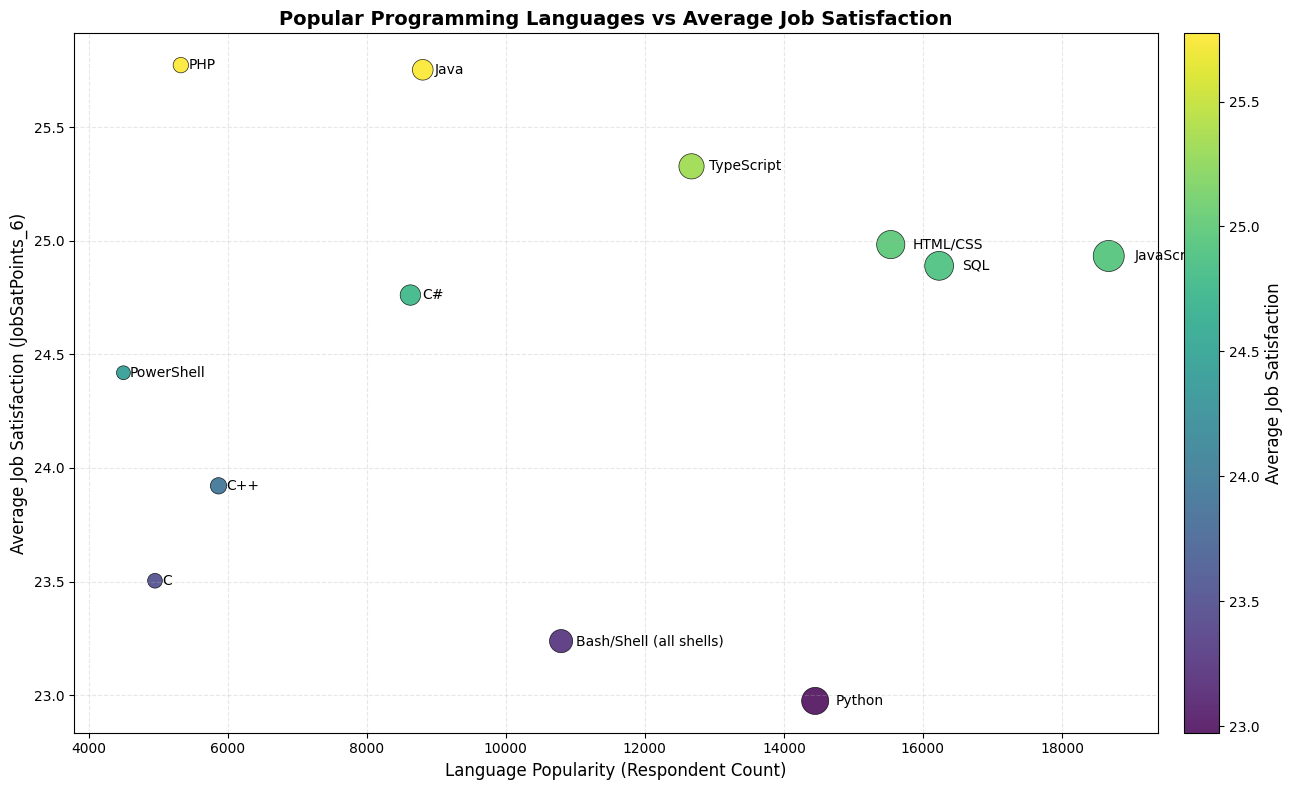

In [32]:
# Prepare the language-level popularity and satisfaction summary
lang_df = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()
lang_df = lang_df[lang_df['LanguageHaveWorkedWith'].astype(str).str.strip() != '']
lang_df = lang_df.assign(Language=lang_df['LanguageHaveWorkedWith'].str.split(';')).explode('Language')
lang_df['Language'] = lang_df['Language'].str.strip()

lang_stats = (
    lang_df.groupby('Language')
    .agg(popularity=('Language', 'size'), avg_satisfaction=('JobSatPoints_6', 'mean'))
    .sort_values('popularity', ascending=False)
)

top_languages = lang_stats.head(12)

plt.figure(figsize=(14, 8))
sizes = ((top_languages['popularity'] - top_languages['popularity'].min()) /
         (top_languages['popularity'].max() - top_languages['popularity'].min() + 1) * 400) + 100
scatter = plt.scatter(
    top_languages['popularity'],
    top_languages['avg_satisfaction'],
    s=sizes,
    c=top_languages['avg_satisfaction'],
    cmap='viridis',
    alpha=0.85,
    edgecolors='k',
    linewidth=0.5
)

for i, lang in enumerate(top_languages.index):
    plt.text(
        top_languages['popularity'].iloc[i] * 1.02,
        top_languages['avg_satisfaction'].iloc[i],
        lang,
        fontsize=10,
        va='center'
    )

plt.title('Popular Programming Languages vs Average Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Language Popularity (Respondent Count)', fontsize=12)
plt.ylabel('Average Job Satisfaction (JobSatPoints_6)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Average Job Satisfaction', fontsize=12)
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


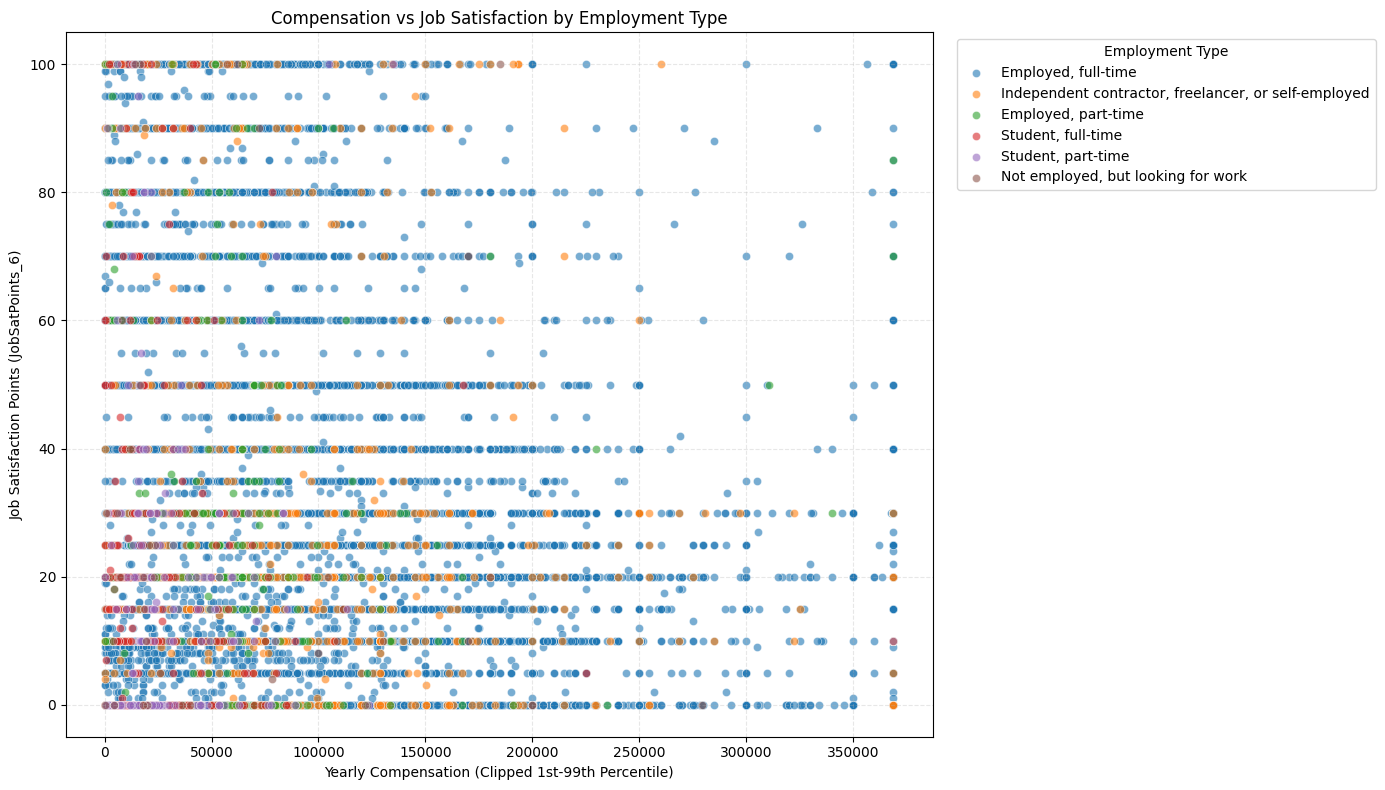

In [50]:
plot_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].dropna().copy()
plot_df = plot_df[plot_df['ConvertedCompYearly'] > 0]
plot_df['JobSatPoints_6'] = pd.to_numeric(plot_df['JobSatPoints_6'], errors='coerce')
plot_df = plot_df.dropna(subset=['JobSatPoints_6'])
plot_df['Employment_primary'] = plot_df['Employment'].str.split(';').str[0].str.strip()

comp_min, comp_max = plot_df['ConvertedCompYearly'].quantile([0.01, 0.99])
plot_df['CompClipped'] = plot_df['ConvertedCompYearly'].clip(lower=comp_min, upper=comp_max)

employment_types = plot_df['Employment_primary'].value_counts().head(7).index
palette = plt.cm.tab10.colors

plt.figure(figsize=(14, 8))
for idx, employment in enumerate(employment_types):
    subset = plot_df[plot_df['Employment_primary'] == employment]
    plt.scatter(
        subset['CompClipped'],
        subset['JobSatPoints_6'],
        label=employment,
        alpha=0.6,
        s=35,
        color=palette[idx % len(palette)],
        edgecolors='w',
        linewidth=0.5
    )

plt.title('Compensation vs Job Satisfaction by Employment Type')
plt.xlabel('Yearly Compensation (Clipped 1st-99th Percentile)')
plt.ylabel('Job Satisfaction Points (JobSatPoints_6)')
plt.legend(title='Employment Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


C:\Users\awais\AppData\Local\Temp\ipykernel_6844\5006636.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(top_countries))


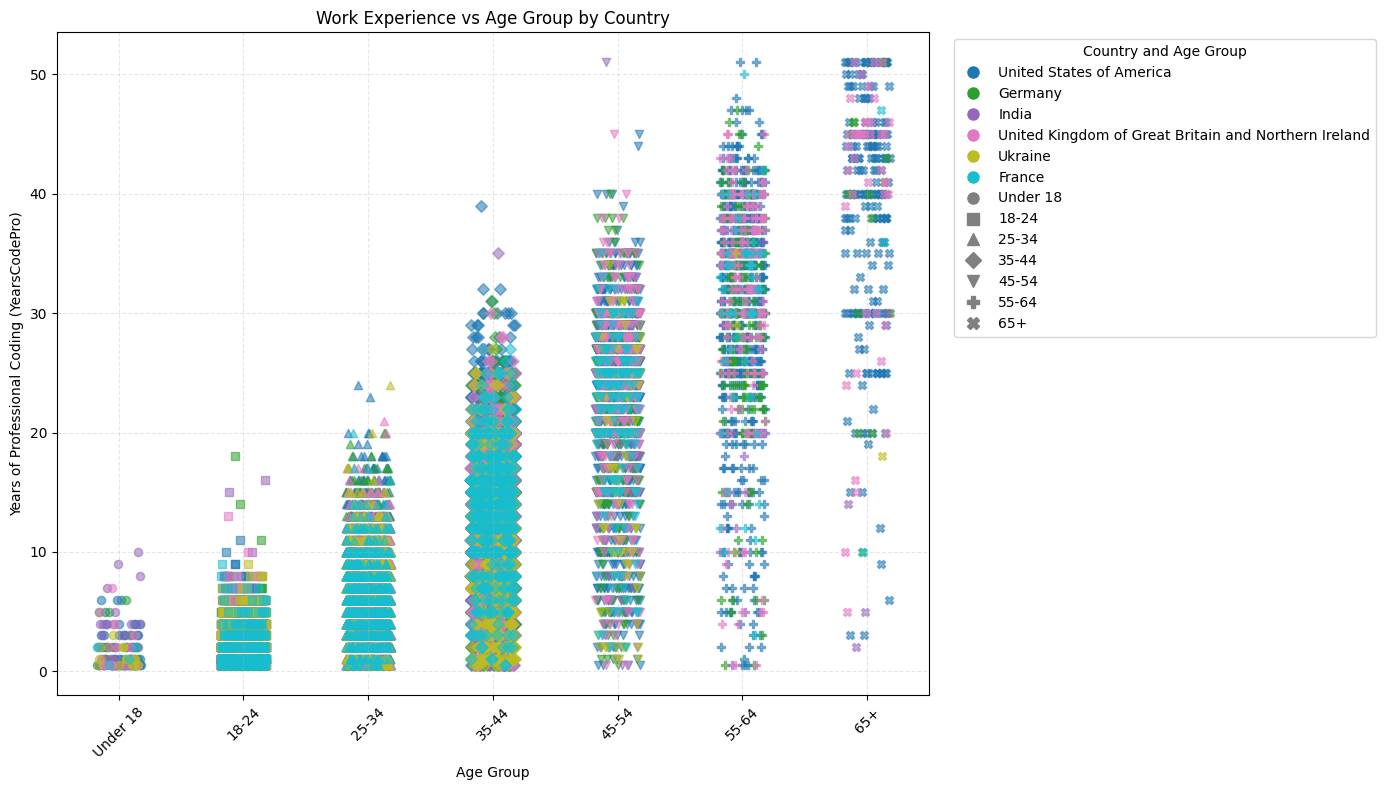

In [51]:
age_labels = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'
}

def parse_years(value):
    if pd.isna(value):
        return np.nan
    if value == 'Less than 1 year':
        return 0.5
    if value == 'More than 50 years':
        return 51
    try:
        return float(value)
    except ValueError:
        return np.nan

wc_df = df[['Age', 'YearsCodePro', 'Country']].dropna().copy()
wc_df['Age_group'] = wc_df['Age'].map(age_labels)
wc_df['YearsCodePro_num'] = wc_df['YearsCodePro'].apply(parse_years)
wc_df = wc_df.dropna(subset=['Age_group', 'YearsCodePro_num'])

age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
wc_df['Age_group'] = pd.Categorical(wc_df['Age_group'], categories=age_order, ordered=True)

top_countries = wc_df['Country'].value_counts().head(6).index
wc_df = wc_df[wc_df['Country'].isin(top_countries)]

markers = ['o', 's', '^', 'D', 'v', 'P', 'X']
marker_map = dict(zip(age_order, markers))
cmap = plt.cm.get_cmap('tab10', len(top_countries))

plt.figure(figsize=(14, 8))
for country_idx, country in enumerate(top_countries):
    for age_group in age_order:
        subset = wc_df[(wc_df['Country'] == country) & (wc_df['Age_group'] == age_group)]
        if subset.empty:
            continue
        x = subset['Age_group'].cat.codes + np.random.uniform(-0.18, 0.18, size=len(subset))
        plt.scatter(
            x,
            subset['YearsCodePro_num'],
            alpha=0.55,
            s=35,
            color=cmap(country_idx),
            marker=marker_map[age_group]
        )

plt.xticks(range(len(age_order)), age_order, rotation=45)
plt.title('Work Experience vs Age Group by Country')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Coding (YearsCodePro)')

from matplotlib.lines import Line2D
country_handles = [
    Line2D([0], [0], marker='o', color=cmap(idx), linestyle='', markersize=8, label=country)
    for idx, country in enumerate(top_countries)
]
age_handles = [
    Line2D([0], [0], marker=marker_map[age], color='gray', linestyle='', markersize=8, label=age)
    for age in age_order
]
plt.legend(
    handles=country_handles + age_handles,
    title='Country and Age Group',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
